# HC3 data exploration

Day-1 exploration: domain sizes, a manual sample read-through of a few question/human/chatgpt triples per domain, and the human-vs-chatgpt word-count distributions that motivated the length-control strategy used in `src/data_utils.py`.

Run this with the project venv kernel (`.venv`).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'src'))

import pandas as pd
from data_utils import load_hc3

pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 80)

df = load_hc3()
print(df.shape)
df.head()

(24322, 5)


,question,human_answers,chatgpt_answers,index,source
0,"Why is every book I hear about a "" NY Times # 1 Best Seller "" ? ELI5 : Why i...","[Basically there are many categories of "" Best Seller "" . Replace "" Best Sel...",[There are many different best seller lists that are published by various or...,NaN,reddit_eli5
1,"If salt is so bad for cars , why do we use it on the roads ? As the title st...",[salt is good for not dying in car crashes and car crashes are worse for car...,[Salt is used on roads to help melt ice and snow and improve traction during...,NaN,reddit_eli5
2,Why do we still have SD TV channels when HD looks like SD on an old TV ? Cou...,[The way it works is that old TV stations got a certain amount of bandwidth ...,[There are a few reasons why we still have SD (standard definition) TV chann...,NaN,reddit_eli5
3,Why has nobody assassinated Kim Jong - un He is such a pest and nuisance to ...,[You ca n't just go around assassinating the leaders of countries you do nt ...,[It is generally not acceptable or ethical to advocate for or condone the as...,NaN,reddit_eli5
4,How was airplane technology able to advance so quickly after the Wright Brot...,"[Wanting to kill the shit out of Germans drives innovation ., This is a freq...","[After the Wright Brothers made the first powered flight in 1903, people all...",NaN,reddit_eli5


## Domain sizes

`reddit_eli5` is by far the largest and most general-topic domain — the one we scoped down to for training (see project decision log).

In [2]:
df["source"].value_counts()

source
reddit_eli5    17112
finance         3933
medicine        1248
open_qa         1187
wiki_csai        842
Name: count, dtype: int64

## Sample read-through

A few question/human/chatgpt triples per domain, to sanity-check topic matching and look for obvious tells.

In [3]:
for src in df["source"].unique():
    sub = df[df["source"] == src].sample(n=min(2, len(df[df["source"] == src])), random_state=42)
    for _, row in sub.iterrows():
        print(f"\n--- domain: {src} ---")
        print("Q:", row["question"][:200])
        h = row["human_answers"][0] if row["human_answers"] else ""
        c = row["chatgpt_answers"][0] if row["chatgpt_answers"] else ""
        print("HUMAN:", h[:300])
        print("CHATGPT:", c[:300])


--- domain: reddit_eli5 ---
Q: Why does time seem to pass quicker as you get older ? I am 33 . Will a year seem to go by twice as fast when I am 66 ? Explain like I'm five.
HUMAN: I 've heard three theories . The first , as MegainPhoto has pointed out , is relativity ; at 5 years old , a year is 20 % of your life , so it seems huge . At 50 years old , a year is 2 % of your life , so it seems like very little . The second is new experiences . This theory suggests that your bra
CHATGPT: Time seems to pass more quickly as you get older because your brain is processing information and experiences at a faster rate. When you are young, every experience is new and exciting, so it feels like there is more time to do things. As you get older, you have more experiences and your brain proce

--- domain: reddit_eli5 ---
Q: is the way we walk genetic ? So i have noticed my cousin walks similarly of not exactly the same as my uncle . I feel like I also kinda walk like my dad . Is this just another 

## Word-count distributions: human vs. chatgpt

**Key finding**: ChatGPT answers are systematically longer and much lower-variance than human answers. This is the length-shortcut risk that motivates the `length_control` option in `flatten_to_binary()` — without it, a classifier could reach high accuracy by learning "length ≈ 150-220 words, low variance → AI" without ever touching style.

HUMAN   :
 count    58546.000000
mean       133.857394
std        163.849899
min          1.000000
25%         42.000000
50%         83.000000
75%        162.000000
max       7904.000000
dtype: float64

CHATGPT :
 count    26903.000000
mean       173.070141
std         61.569948
min          0.000000
25%        131.000000
50%        174.000000
75%        212.000000
max        639.000000
dtype: float64


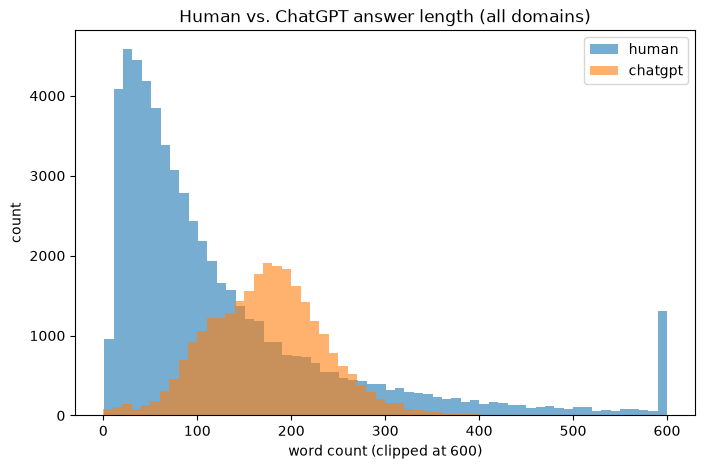

In [4]:
import matplotlib.pyplot as plt


def word_counts(answer_list):
    return [len(a.split()) for a in answer_list] if isinstance(answer_list, list) else []


df["human_wc"] = df["human_answers"].apply(word_counts)
df["chatgpt_wc"] = df["chatgpt_answers"].apply(word_counts)

human_wc_flat = pd.Series([wc for lst in df["human_wc"] for wc in lst])
chatgpt_wc_flat = pd.Series([wc for lst in df["chatgpt_wc"] for wc in lst])

print("HUMAN   :\n", human_wc_flat.describe())
print("\nCHATGPT :\n", chatgpt_wc_flat.describe())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(human_wc_flat.clip(upper=600), bins=60, alpha=0.6, label="human")
ax.hist(chatgpt_wc_flat.clip(upper=600), bins=60, alpha=0.6, label="chatgpt")
ax.set_xlabel("word count (clipped at 600)")
ax.set_ylabel("count")
ax.legend()
ax.set_title("Human vs. ChatGPT answer length (all domains)")
plt.show()

In [5]:
per_domain = []
for src in df["source"].unique():
    sub = df[df["source"] == src]
    h = pd.Series([wc for lst in sub["human_wc"] for wc in lst])
    c = pd.Series([wc for lst in sub["chatgpt_wc"] for wc in lst])
    per_domain.append({
        "domain": src,
        "n_rows": len(sub),
        "human_median_wc": h.median(),
        "chatgpt_median_wc": c.median(),
        "human_mean_wc": h.mean(),
        "chatgpt_mean_wc": c.mean(),
    })
pd.DataFrame(per_domain)

,domain,n_rows,human_median_wc,chatgpt_median_wc,human_mean_wc,chatgpt_mean_wc
0,reddit_eli5,17112,82.0,173.0,133.270921,174.876471
1,open_qa,1187,27.0,106.0,31.398484,117.856501
2,wiki_csai,842,166.0,187.5,195.454869,185.337292
3,finance,3933,129.0,205.0,175.634630,203.797913
4,medicine,1248,74.0,184.0,82.215545,186.403141
